# LLaVA VQA (Web 동일 로직)

이 노트북은 웹 데모(`LLaVA VQA`)와 동일한 모델/프롬프트 포맷으로, `img/xai506_example_image.jpg`를 입력으로 VQA를 실행합니다.

- Model: `llava-hf/llava-1.5-7b-hf`
- Input image: `img/xai506_example_image.jpg`
- Prompt format: `USER: <image> ... ASSISTANT:` (웹 API와 동일)


In [1]:
!pip install -q transformers torch pillow huggingface_hub matplotlib

/opt/conda/envs/diff-bridge/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Image path: img/xai506_example_image.jpg
Device: cuda, dtype: torch.float16


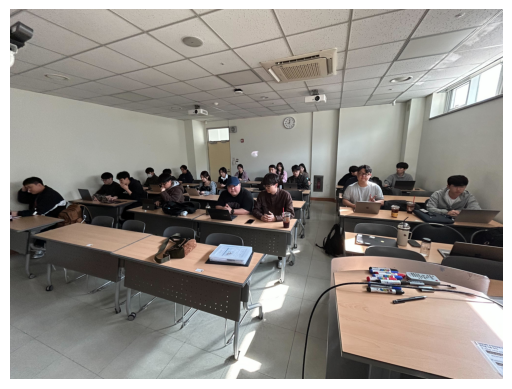

In [2]:
import torch
from PIL import Image
from transformers import AutoProcessor, LlavaForConditionalGeneration
import matplotlib.pyplot as plt

MODEL_ID = 'llava-hf/llava-1.5-7b-hf'
IMAGE_PATH = 'img/xai506_example_image.jpg'


device = torch.device('cuda')
dtype = torch.float16 if device.type == 'cuda' else torch.float32

print(f'Image path: {IMAGE_PATH}')
print(f'Device: {device}, dtype: {dtype}')

image = Image.open(IMAGE_PATH).convert('RGB')
plt.imshow(image)
plt.axis('off')
plt.show()


In [3]:
# 웹 API(get_llava_model)와 동일 구성
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    attn_implementation='eager',
).to(device)
model.eval()
print('Model loaded.')


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 27.94it/s]


Model loaded.


In [4]:
@torch.no_grad()
def run_llava_vqa(image: Image.Image, question: str, max_new_tokens: int = 128, temperature: float = 0.2):
    prompt = f'USER: <image>\n{question.strip()}\nASSISTANT:'

    inputs = processor(images=image, text=prompt, return_tensors='pt')

    model_inputs = {}
    for k, v in inputs.items():
        if torch.is_tensor(v):
            if k == 'pixel_values':
                model_inputs[k] = v.to(device=device, dtype=dtype)
            else:
                model_inputs[k] = v.to(device=device)
        else:
            model_inputs[k] = v

    do_sample = temperature > 0
    generation_kwargs = {
        'max_new_tokens': max(1, int(max_new_tokens)),
        'do_sample': do_sample,
    }
    if do_sample:
        generation_kwargs['temperature'] = max(float(temperature), 1e-4)

    generation = model.generate(**model_inputs, **generation_kwargs)

    prompt_len = model_inputs['input_ids'].shape[1]
    answer_tokens = generation[:, prompt_len:]

    if answer_tokens.shape[1] == 0:
        decoded = processor.batch_decode(generation, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
        answer = decoded.replace(prompt, '').strip()
    else:
        answer = processor.batch_decode(
            answer_tokens,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0].strip()

    return {
        'answer': answer,
        'prompt': prompt,
        'model_id': MODEL_ID,
        'device': str(device),
        'dtype': str(dtype).replace('torch.', ''),
    }


In [6]:
question = 'What is happening in this image? Please answer in Korean.'
max_new_tokens = 256
temperature = 0.2

result = run_llava_vqa(
    image=image,
    question=question,
    max_new_tokens=max_new_tokens,
    temperature=temperature,
)

print('Model:', result['model_id'])
print('Device:', result['device'])
print('DType:', result['dtype'])
print('--- Question ---')
print(question)
print('--- Answer ---')
print(result['answer'])


Model: llava-hf/llava-1.5-7b-hf
Device: cuda
DType: float16
--- Question ---
What is happening in this image? Please answer in Korean.
--- Answer ---
이 이미지에서는 학생들이 학교에서 수업을 듣고 있는 모습을 볼 수 있습니다. 학생들은 컴퓨터와 라피를 사용하며, 책과 커피잔을 볼 수 있습니다. 이 모습은 학생들이 집중하고 있는 학습 환경을 보여줍니다.
